----------------------------------------------------------------------------------------
1. Import libraries 
----------------------------------------------------------------------------------------

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from scipy.optimize import minimize

----------------------------------------------------------------------------------------
2. Load csv data (5 years)
----------------------------------------------------------------------------------------

In [2]:
folder_path = "/Users/federidogaravaglia/Desktop/Backup/csv"
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

all_returns = []

for file in csv_files:
    df = pd.read_csv(file, parse_dates=["Date"], dayfirst=True)
    df = df.sort_values("Date")

    price_col = "Close" if "Close" in df.columns else "Close"

    df[price_col] = pd.to_numeric(df[price_col], errors="coerce")

    df["Return"] = df[price_col].pct_change(fill_method=None)

    stock_name = os.path.basename(file).replace(".csv", "")
    df = df[["Date", "Return"]].rename(columns={"Return": stock_name})
    
    all_returns.append(df)

combined = all_returns[0]
for df in all_returns[1:]:
    combined = pd.merge(combined, df, on="Date", how="outer")

combined = combined.sort_values("Date")

start_date = "2021-01-01"
end_date = "2026-01-01"

mask = (combined["Date"] >= start_date) & (combined["Date"] <= end_date)
combined_filtered = combined.loc[mask]

print(combined_filtered.head())

           Date      SPY2      SPYW      IMAE      DBXT      VAGF      VGEA  \
2914 2021-01-04 -0.024258  0.010863  0.006987 -0.000074       NaN       NaN   
2915 2021-01-05  0.002040 -0.006493 -0.001643  0.000000 -0.001131 -0.001079   
2916 2021-01-06  0.004065  0.017199  0.014265  0.000000 -0.004530 -0.002161   
2917 2021-01-07 -0.006666  0.008954  0.005049  0.000000  0.000000  0.000000   
2918 2021-01-08  0.005598  0.003753  0.006638 -0.000074  0.000000  0.001444   

          VECA      IUSN      SPYM      IWDA  
2914       NaN -0.007825  0.010555 -0.007372  
2915 -0.001116  0.011041  0.011942  0.005364  
2916  0.000000  0.023401 -0.003480  0.005882  
2917  0.000931  0.012195  0.005667  0.012920  
2918  0.000372  0.003012  0.023281  0.006982  


----------------------------------------------------------------------------------------
3. Cleaning data - For missing data forward-filling has been used to avoid look-ahead bias. For the residual gaps, interpolation has been applied so time-series are consistent.
----------------------------------------------------------------------------------------

In [3]:
df.set_index("Date", inplace=True)
# print(combined_filtered.isnull().sum())
combined_filtered = combined_filtered.sort_index()
combined_filtered = combined_filtered.ffill()
combined_filtered = combined_filtered.interpolate(method="linear") 
# print(combined_filtered.isnull().sum())
combined_filtered.head()


,Date,SPY2,SPYW,IMAE,DBXT,VAGF,VGEA,VECA,IUSN,SPYM,IWDA
2914,2021-01-04,-0.024258,0.010863,0.006987,-0.000074,NaN,NaN,NaN,-0.007825,0.010555,-0.007372
2915,2021-01-05,0.002040,-0.006493,-0.001643,0.000000,-0.001131,-0.001079,-0.001116,0.011041,0.011942,0.005364
2916,2021-01-06,0.004065,0.017199,0.014265,0.000000,-0.004530,-0.002161,0.000000,0.023401,-0.003480,0.005882
2917,2021-01-07,-0.006666,0.008954,0.005049,0.000000,0.000000,0.000000,0.000931,0.012195,0.005667,0.012920
2918,2021-01-08,0.005598,0.003753,0.006638,-0.000074,0.000000,0.001444,0.000372,0.003012,0.023281,0.006982


----------------------------------------------------------------------------------------
4. Compute and plot cumulative returns
----------------------------------------------------------------------------------------

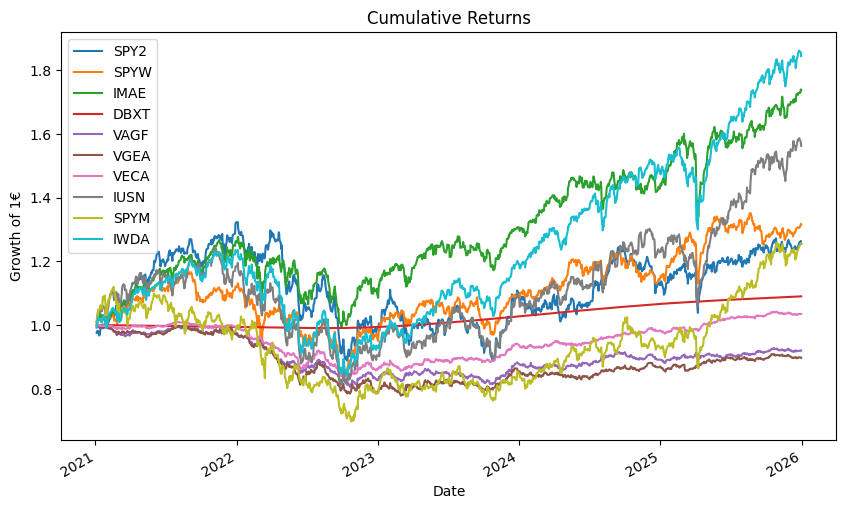

In [4]:
combined_filtered["Date"] = pd.to_datetime(combined_filtered["Date"])
combined_filtered.set_index("Date", inplace=True)
returns = combined_filtered
cumulative_returns = (1 + returns).cumprod() 
# cumulative_returns.tail() 
cumulative_returns.plot(figsize = (10, 6)) 
plt.title("Cumulative Returns") 
plt.xlabel("Date")
plt.ylabel("Growth of 1€")
# plt.show()
plt.savefig("../outputs/charts/cumulative_returns.png", dpi=300)
# plt.close()

----------------------------------------------------------------------------------------
5. Compute portfolio return (cumulative, total, CAGR) and annualized volatility - dot product between the returns matrix and the weight vector to obtain the time-series of portfolio returns
----------------------------------------------------------------------------------------

In [5]:
weights = np.array([0.15, 0.36, 0.10, 0.08, 0.06, 0.07, 0.06, 0.03, 0.06, 0.03])
# print(weights.sum())
portfolio_returns = returns.dot(weights) 
portfolio_returns.head()
# same as portfolio_returns = (returns * weights).sum(axis=1)
portfolio_cumulative_returns = (1 + portfolio_returns).cumprod() 
total_return = portfolio_cumulative_returns.iloc[-1] - 1
# print(total_return)
n_days = len(portfolio_returns)
n_years = n_days / 252
final_value = portfolio_cumulative_returns.iloc[-1] 
cagr = final_value**(1 / n_years) - 1
# print(cagr)
volatility = portfolio_returns.std() * np.sqrt(252)
# print(volatility)

----------------------------------------------------------------------------------------
6. Compute annualized portfolio and assets Sharpe (hp, rf = 3%, €STR 2-4%)
----------------------------------------------------------------------------------------

In [6]:
risk_free = 0.03
rf_daily = risk_free / 252
excess_returns = portfolio_returns - risk_free
sharpe_ratio = (excess_returns.mean() * 252) / volatility
# print(sharpe_ratio)
asset_excess_returns = returns - risk_free
asset_sharpe = (asset_excess_returns.mean() * 252) / (returns.std() * np.sqrt(252)) 
asset_sharpe_df = asset_sharpe.sort_values(ascending=False).to_frame(name="Sharpe Ratio") 
asset_sharpe_df.index.name = "Asset"
asset_sharpe_df["Sharpe Ratio"] = asset_sharpe_df["Sharpe Ratio"].round(2)
# print(asset_sharpe_df)

----------------------------------------------------------------------------------------
7. Compute portfolio max drawdown
----------------------------------------------------------------------------------------

In [7]:
running_max = portfolio_cumulative_returns.cummax()
drawdown = (portfolio_cumulative_returns - running_max) / running_max 
max_drawdown = drawdown.min()
# print(max_drawdown)

----------------------------------------------------------------------------------------
8. Portfolio visualizations (cumulative returns, drawdown)
----------------------------------------------------------------------------------------

<Figure size 1000x600 with 0 Axes>

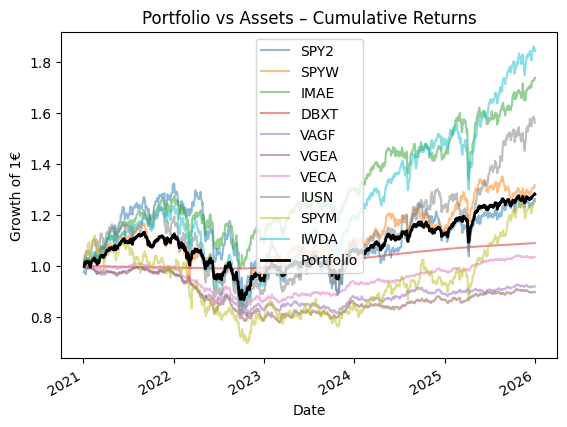

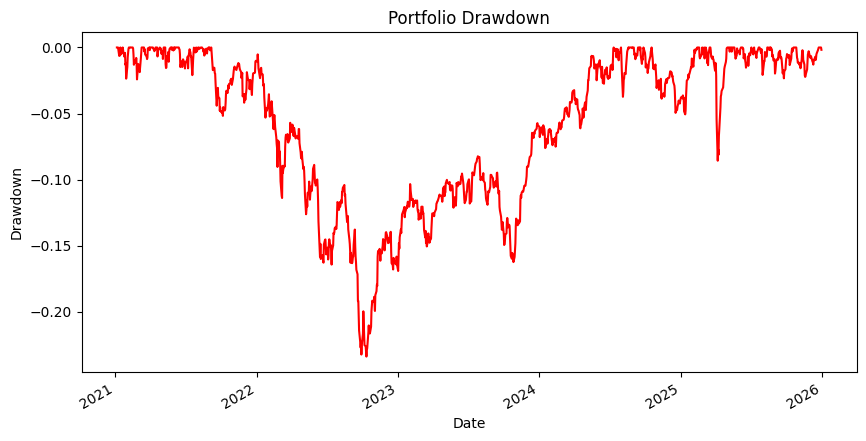

In [8]:
plt.figure(figsize = (10, 6))
cumulative_returns.plot(alpha = 0.5)
portfolio_cumulative_returns.plot(color = "black", linewidth = 2, label = "Portfolio") 
plt.title("Portfolio vs Assets – Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Growth of 1€")
plt.legend()
# plt.show()
plt.savefig("../outputs/charts/portfolio_vs_assets.png", dpi=300)
# plt.close()
plt.figure(figsize = (10, 5))
drawdown.plot(color = "red")
plt.title("Portfolio Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
# plt.show()
plt.savefig("../outputs/charts/drawdown.png", dpi=300)
# plt.close()

----------------------------------------------------------------------------------------
9. [Benchmark] – Load and clean data
----------------------------------------------------------------------------------------

In [9]:
benchmark_prices = pd.read_csv("/Users/federidogaravaglia/Desktop/Backup/csv/IWDA.csv")
benchmark_prices.head()
benchmark_prices["Close"] = pd.to_numeric(benchmark_prices["Close"], errors="coerce")
benchmark_prices["Date"] = pd.to_datetime(benchmark_prices["Date"], dayfirst=True)
# benchmark_prices["Close"].dtype
# print(benchmark_prices.isnull().sum())
benchmark_prices.set_index("Date", inplace=True)
benchmark_prices = benchmark_prices.sort_index()
benchmark_prices = benchmark_prices.ffill()
benchmark_prices = benchmark_prices.infer_objects(copy=False)
benchmark_prices = benchmark_prices.interpolate(method="linear") 
# print(benchmark_prices.isnull().sum())
# benchmark_prices.head()
benchmark_filtered = benchmark_prices.loc["2021-01-01":"2026-01-01"]
# benchmark_filtered.head(100)

----------------------------------------------------------------------------------------
10. [Benchmark] – Compute and compare cumulative returns
----------------------------------------------------------------------------------------

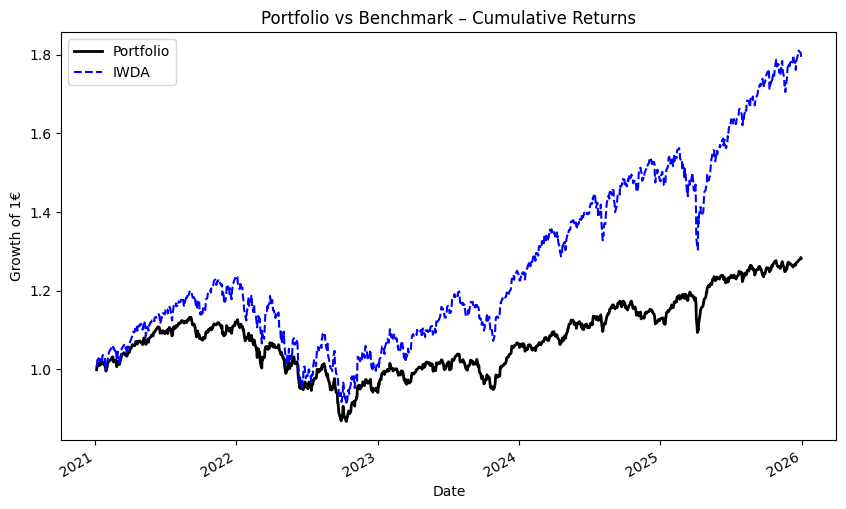

In [10]:
benchmark_returns = benchmark_filtered["Close"].pct_change().dropna() 
benchmark_cumulative_returns = (1 + benchmark_returns).cumprod() 
total_benchmark_return = benchmark_cumulative_returns.iloc[-1] - 1 
benchmark_final_value = benchmark_cumulative_returns.iloc[-1] 
benchmark_cagr = benchmark_final_value**(1 / n_years) - 1 
plt.figure(figsize = (10,6))
portfolio_cumulative_returns.plot(color = "black", linewidth = 2, label = "Portfolio") 
benchmark_cumulative_returns.plot(color = "blue", linestyle = "--", label = "IWDA") 
plt.title("Portfolio vs Benchmark – Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Growth of 1€")
plt.legend()
# plt.show() 
plt.savefig("../outputs/charts/portfolio_vs_benchmark.png", dpi=300) 
# # plt.close()

----------------------------------------------------------------------------------------
11. [Benchmark] – Compute and compare Sharpe ratios
----------------------------------------------------------------------------------------

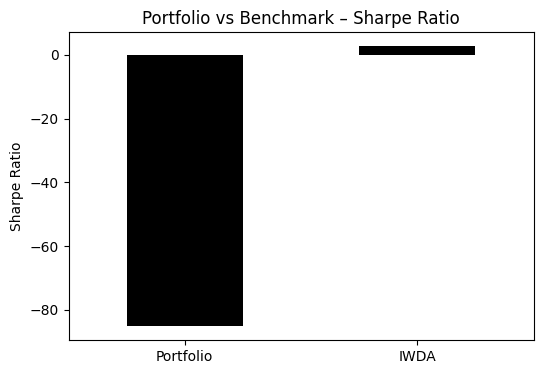

In [11]:
benchmark_excess = benchmark_returns - rf_daily
benchmark_volatility = benchmark_returns.std() * np.sqrt(252**0.5)
benchmark_sharpe = (benchmark_excess.mean() * 252) / benchmark_volatility
sharpe_comparison = pd.DataFrame({"Sharpe Ratio": [sharpe_ratio, benchmark_sharpe]}, index=["Portfolio", "IWDA"])
sharpe_comparison = sharpe_comparison.round(2)
# print(sharpe_comparison)
sharpe_comparison.plot(kind="bar", figsize=(6,4), legend=False, color=["black", "blue"]) 
plt.title("Portfolio vs Benchmark – Sharpe Ratio")
plt.ylabel("Sharpe Ratio")
plt.xticks(rotation=0)
# plt.show()
plt.savefig("../outputs/charts/sharpe_comparison.png", dpi=300)
# plt.close()

----------------------------------------------------------------------------------------
12. [Benchmark] – Compute and compare max drawdown
----------------------------------------------------------------------------------------

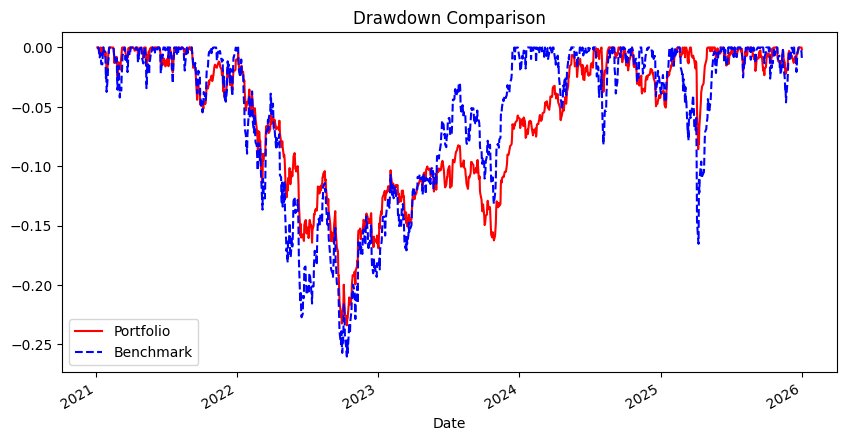

In [12]:
benchmark_running_max = benchmark_cumulative_returns.cummax()
benchmark_drawdown = (benchmark_cumulative_returns - benchmark_running_max) / benchmark_running_max
max_benchmark_drawdown = benchmark_drawdown.min()
max_drawdown_comparison = pd.DataFrame({"Max Drawdown": [drawdown.min(),benchmark_drawdown.min()]}, index=['Portfolio', "IWDA"])
max_drawdown_comparison = max_drawdown_comparison.round(2)
# print(max_drawdown_comparison)
plt.figure(figsize = (10,5))
drawdown.plot(label = "Portfolio", color = "red") 
benchmark_drawdown.plot(label = "Benchmark", color = "blue", linestyle = "--") 
plt.title("Drawdown Comparison")
plt.legend()
# plt.show()
plt.savefig("../outputs/charts/drawdown_comparison.png", dpi=300)
# plt.close()

----------------------------------------------------------------------------------------
13. Outcome Portfolio vs Benchmark
----------------------------------------------------------------------------------------

In [13]:
sharpe_tolerance = 0.05
drawdown_tolerance = 0.01
sharpe_difference = sharpe_ratio - benchmark_sharpe 
drawdown_difference = max_drawdown - max_benchmark_drawdown 
if sharpe_difference > sharpe_tolerance:
    sharpe_result = "Portfolio outperformed the Benchmark"
elif sharpe_difference < -sharpe_tolerance:
    sharpe_result = "Portfolio underperformed the Benchmark" 
else:
    sharpe_result = "Portfolio performed in line with the Benchmark"
    
if drawdown_difference > drawdown_tolerance:
    drawdown_result = "Portfolio had worse downside than the Benchmark"
elif drawdown_difference < - drawdown_tolerance:
    drawdown_result = "Portfolio had better downside protection than the Benchmark"
else:
    drawdown_result = "Portfolio drawdown was in line with the Benchmark"

----------------------------------------------------------------------------------------
14. Summary of calculated metrics
----------------------------------------------------------------------------------------

In [16]:
print("\n=== PORTFOLIO SUMMARY ===\n")
print("Portfolio Total return: {}".format(total_return))
print("Portfolio CAGR: {}" .format(cagr))
print("Portfolio Volatility: {}" .format(volatility))
print("Portfolio Sharpe Ratio: {}" .format(sharpe_ratio))
print("Portfolio Max Drawdown: {}" .format(max_drawdown))
print("\n=== BENCHMARK SUMMARY ===\n")
print("Benchmark Total return: {}" .format(total_benchmark_return)) 
print("Benchmark CAGR: {}" .format(benchmark_cagr))
print("Benchmark Volatility: {}" .format(benchmark_volatility)) 
print("Benchmark Sharpe Ratio: {}" .format(benchmark_sharpe)) 
print("Benchmark Max Drawdown: {}" .format(max_benchmark_drawdown)) 
print("\n=== PERFORMANCE ASSESSMENT ===\n")
print("Sharpe comparison: {}" .format(sharpe_result)) 
print("Drawdown comparison: {}" .format(drawdown_result))


=== PORTFOLIO SUMMARY ===

Portfolio Total return: 0.28195871858000476
Portfolio CAGR: 0.04960085284290461
Portfolio Volatility: 0.08811899700277437
Portfolio Sharpe Ratio: -85.19913706362445
Portfolio Max Drawdown: -0.23407658217484048

=== BENCHMARK SUMMARY ===

Benchmark Total return: 0.7931508733324126
Benchmark CAGR: 0.12054371113778672
Benchmark Volatility: 0.036258177759760105
Benchmark Sharpe Ratio: 2.6771455555969323
Benchmark Max Drawdown: -0.260360962566845

=== PERFORMANCE ASSESSMENT ===

Sharpe comparison: Portfolio underperformed the Benchmark
Drawdown comparison: Portfolio had worse downside than the Benchmark
